In [1]:
import pandas as pd
from src import *
allimages = pd.read_csv("Tables/All_Subjects_All_Images_20Feb2026.csv")
diagnosis = pd.read_csv("Tables/All_Subjects_DXSUM_20Feb2026.csv")

In [2]:
# Load table of all images
allimages = pd.read_csv("Tables/All_Subjects_All_Images_20Feb2026.csv")

In [3]:
len(allimages[allimages.modality=="MRI"])


230002

In [5]:
temp = allimages[allimages.image_type=='Pre-processed']
temp[(temp.phase=="ADNI 3")&temp.image_description.str.contains("T1 ")&(temp.modality=="MRI")]


,image_id,subject_id,phase,study_id,modality,image_type,image_visit,image_date,image_description,upload_date,file_format,structure,laterality
273807,11380943,127_S_1427,ADNI 3,115027,MRI,Pre-processed,init,2017-09-06,Reoriented T1 Image,2025-07-24,NIfTI,Brain,Both
273808,11380944,127_S_1427,ADNI 3,115027,MRI,Pre-processed,init,2017-09-06,T1 Brain Mask,2025-07-24,NIfTI,Brain,Both
273809,11380949,127_S_1427,ADNI 3,115027,MRI,Pre-processed,init,2017-09-06,T1 MUSE segmentation,2025-07-24,NIfTI,Brain,Both
273819,11386554,127_S_1427,ADNI 3,127633,MRI,Pre-processed,y1,2018-10-12,Reoriented T1 Image,2025-07-28,NIfTI,Brain,Both
273820,11386556,127_S_1427,ADNI 3,127633,MRI,Pre-processed,y1,2018-10-12,T1 Brain Mask,2025-07-28,NIfTI,Brain,Both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
335985,11365077,035_S_7115,ADNI 3,218809,MRI,Pre-processed,sc,2022-11-15,T1 Brain Mask,2025-07-23,NIfTI,Brain,Both
335986,11365082,035_S_7115,ADNI 3,218809,MRI,Pre-processed,sc,2022-11-15,T1 MUSE segmentation,2025-07-23,NIfTI,Brain,Both
336023,11365090,082_S_7117,ADNI 3,219059,MRI,Pre-processed,sc,2022-11-03,Reoriented T1 Image,2025-07-23,NIfTI,Brain,Both
336024,11365095,082_S_7117,ADNI 3,219059,MRI,Pre-processed,sc,2022-11-03,T1 Brain Mask,2025-07-23,NIfTI,Brain,Both


In [6]:
mris = allimages[
    (allimages.modality=="MRI")&
    (allimages.image_type=="Original")
    ]

In [7]:
mris.image_description.value_counts()[:50]

image_description
3 Plane Localizer                      12014
localizer                               7604
Axial 3D ME T2 GRE (MSV21)              7183
3-plane localizer                       5823
MPRAGE                                  5558
Field Mapping                           5522
Axial PD-T2 TSE                         3942
Axial PD/T2 FSE                         3822
Localizer                               3288
Axial T2-FLAIR                          3041
Axial T2 Star                           2370
Sagittal 3D FLAIR                       2324
Axial 3TE T2 STAR                       2256
AXIAL_T2_STAR                           2075
MPRAGE GRAPPA2                          2061
MP-RAGE                                 2037
MPRAGE Repeat                           1961
B1-calibration Body                     1897
B1-calibration Head                     1866
MP-RAGE REPEAT                          1669
HighResHippo                            1487
B1-Calibration Body                  

In [8]:
mris.subject_id.value_counts()[-10:]

subject_id
404_S_10895    4
404_S_10853    4
404_S_10898    4
005_S_10446    3
381_S_10578    3
941_S_10010    3
100_S_10035    3
073_S_10228    3
005_S_10240    3
022_S_10055    2
Name: count, dtype: int64

In [9]:
mris34 = mris[(mris.phase=="ADNI 3")|(mris.phase=="ADNI 4")]
len(mris34)

37622

In [10]:
mris3 = mris[(mris.phase=="ADNI 3")]
len(mris3)

25313

In [11]:
mris3.image_description.value_counts()[:50]

image_description
3 Plane Localizer                                                  6648
Field Mapping                                                      4032
Sagittal 3D FLAIR                                                  2314
Axial 3TE T2 STAR                                                  2256
Accelerated Sagittal MPRAGE                                        1438
HighResHippocampus                                                 1410
Axial T2 Star                                                      1320
Axial Field Mapping                                                 570
Axial T2 STAR                                                       543
HighResHippo                                                        536
Calibration Scan                                                    375
Sagittal 3D Accelerated MPRAGE                                      353
HighResHippo Scan (Oblique - perpendicular to hippocampal tail      343
Accelerated Sag IR-FSPGR                      

In [12]:
mris34.subject_id.nunique()

1796

In [13]:
mris34.subject_id.value_counts()[1000:1010]

subject_id
003_S_10158    14
073_S_10167    14
073_S_10172    14
941_S_10148    14
389_S_10140    14
022_S_10136    14
014_S_10180    14
073_S_10089    14
052_S_10242    14
016_S_10190    14
Name: count, dtype: int64

In [14]:
# Load table of diagnosis
diagnosis = pd.read_csv("Tables/All_Subjects_DXSUM_20Feb2026.csv")
diagnosis.USERDATE = diagnosis.USERDATE.apply(pd.to_datetime)
diagnosis34 = diagnosis[
    (diagnosis.PHASE=="ADNI3")
    ]

In [15]:
diagnosis_ = {}
for i in [1,"GO",2,3,4]:
    diagnosis_[i] = diagnosis[diagnosis.PHASE==f"ADNI{i}"]

In [16]:
for i in [1,"GO",2,3,4]:
    print(f"Count of patients in phase {i}: {diagnosis_[i].PTID.nunique()}")

p = [1,"GO",2,3,4]
for i in range(4):
    print(f"Count of patients in phase {p[i]} that didn't continue in phase {p[i+1]}: {diagnosis_[p[i]][~diagnosis_[p[i]].PTID.isin(diagnosis_[p[i+1]].PTID)].PTID.nunique()}")

Count of patients in phase 1: 819
Count of patients in phase GO: 338
Count of patients in phase 2: 1438
Count of patients in phase 3: 1376
Count of patients in phase 4: 1339
Count of patients in phase 1 that didn't continue in phase GO: 610
Count of patients in phase GO that didn't continue in phase 2: 41
Count of patients in phase 2 that didn't continue in phase 3: 1028
Count of patients in phase 3 that didn't continue in phase 4: 860


In [17]:
diagnosis.PTID.nunique()

3789

In [18]:
diagnosis[diagnosis.PTID=="007_S_6341"]

,PHASE,PTID,RID,VISCODE,VISCODE2,EXAMDATE,DIAGNOSIS,DXNORM,DXNODEP,DXMCI,...,DXODES,DXCONFID,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
10729,ADNI3,007_S_6341,6341,sc,sc,2018-04-30,2.0,NaN,NaN,NaN,...,NaN,NaN,41028,5,2018-05-04,2018-05-04,NaN,NaN,NaN,2018-05-04 22:38:16
10839,ADNI3,007_S_6341,6341,bl,bl,2018-06-07,2.0,NaN,NaN,NaN,...,NaN,NaN,46293,5,2018-06-08,2018-06-08,NaN,NaN,NaN,2018-06-08 22:37:32
11651,ADNI3,007_S_6341,6341,y1,m12,2019-06-11,2.0,NaN,NaN,NaN,...,NaN,NaN,86339,5,2019-06-18,2019-06-18,NaN,NaN,NaN,2019-06-18 09:50:36
12300,ADNI3,007_S_6341,6341,y2,m24,2020-08-19,2.0,NaN,NaN,NaN,...,NaN,NaN,117889,5,2020-08-24,2020-08-26,NaN,NaN,NaN,2020-08-27 04:16:42
12692,ADNI3,007_S_6341,6341,y3,m36,2021-07-19,3.0,NaN,NaN,NaN,...,NaN,NaN,138263,5,2021-07-21,2021-07-21,NaN,NaN,NaN,2021-07-22 04:17:49
13121,ADNI3,007_S_6341,6341,y4,m48,2022-05-24,3.0,NaN,NaN,NaN,...,NaN,NaN,157619,5,2022-05-31,2022-05-31,NaN,NaN,NaN,2022-06-01 04:18:49
13440,ADNI3,007_S_6341,6341,y5,m60,2023-05-16,3.0,NaN,NaN,NaN,...,NaN,NaN,175120,5,2023-05-17,2023-05-17,NaN,NaN,NaN,2023-05-18 04:20:28
13877,ADNI4,007_S_6341,6341,4_init,m72,2024-05-21,3.0,NaN,NaN,NaN,...,NaN,NaN,17265,7,2024-05-28,2024-05-28,v1,e,0.0,2024-05-29 01:39:34


In [19]:
allimages3 = allimages[(allimages.phase=="ADNI 3")&(allimages.modality=="MRI")]

In [20]:
cn = diagnosis34[diagnosis34.DIAGNOSIS==1.0][["PTID","USERDATE","DIAGNOSIS"]]
mci = diagnosis34[diagnosis34.DIAGNOSIS==2.0][["PTID","USERDATE","DIAGNOSIS"]]
ad = diagnosis34[diagnosis34.DIAGNOSIS==3.0][["PTID","USERDATE","DIAGNOSIS"]]

In [21]:
#### Transition patients
patients = pd.merge(mci,ad,on="PTID")
times = patients.groupby("PTID")["USERDATE_y"].max()-patients.groupby("PTID")["USERDATE_x"].min()
cleaned_times = times[times>pd.Timedelta(0)]
times

### always same diagnosis patients:
# patients = mci[(~mci.PTID.isin(cn.PTID))&(~mci.PTID.isin(ad.PTID))]
# times = patients.groupby("PTID")["USERDATE"].max()-patients.groupby("PTID")["USERDATE"].min()
# cleaned_times = times
# times

PTID
003_S_4354   1287 days
006_S_6252    552 days
006_S_6770   1350 days
007_S_4272   1817 days
007_S_4637    324 days
007_S_5265    385 days
007_S_6341   1839 days
012_S_6073   1808 days
014_S_2185    715 days
016_S_6800    607 days
016_S_6939    376 days
018_S_2155   1918 days
019_S_6483   1859 days
019_S_6668   1863 days
021_S_5237   1509 days
022_S_6863    601 days
023_S_4115   1475 days
023_S_6535   1175 days
027_S_6034   1739 days
027_S_6640    874 days
027_S_6788    852 days
033_S_6497   1150 days
033_S_7088    399 days
035_S_4114    733 days
035_S_7000    789 days
036_S_2380    900 days
036_S_4538   1049 days
037_S_0467    781 days
037_S_6222    937 days
041_S_4271    547 days
041_S_6731   1548 days
067_S_4782   1495 days
067_S_6529   1136 days
070_S_6911    433 days
098_S_0896    390 days
099_S_6632   1191 days
114_S_5047   2073 days
126_S_0605   1810 days
126_S_4891   1824 days
126_S_6724   1176 days
127_S_6241   1841 days
128_S_2130   1102 days
128_S_2220   1370 days
129_S_

In [22]:
diagnosis34[diagnosis34.PTID.isin(allimages3.subject_id)].PTID.nunique()

1150

In [23]:
len(cleaned_times)

55

In [24]:
visits = allimages3[allimages3.subject_id.isin(cleaned_times.index)]

In [25]:
visits.groupby("subject_id")["image_date"].unique().apply(len).mean()

np.float64(3.2264150943396226)

In [26]:
visits.groupby("subject_id")["image_date"].unique()

subject_id
003_S_4354     [2017-06-13, 2018-12-19, 2019-06-25, 2021-06-23]
006_S_6252                             [2018-03-05, 2019-05-06]
006_S_6770                 [2019-07-26, 2022-09-01, 2021-09-01]
007_S_4272    [2018-01-16, 2019-01-08, 2020-01-31, 2021-02-2...
007_S_4637     [2017-10-10, 2018-10-16, 2019-10-23, 2022-10-20]
007_S_5265    [2017-09-18, 2018-09-25, 2019-09-17, 2021-09-2...
007_S_6341     [2018-04-30, 2019-06-11, 2020-08-18, 2021-06-28]
012_S_6073     [2017-09-22, 2018-10-31, 2019-10-07, 2021-01-13]
016_S_6800                             [2019-08-19, 2021-03-08]
016_S_6939                             [2021-05-06, 2022-07-08]
018_S_2155    [2017-09-20, 2018-08-28, 2019-09-17, 2020-10-2...
019_S_6483    [2018-07-11, 2019-08-05, 2020-08-04, 2021-08-0...
019_S_6668                 [2019-01-23, 2021-02-16, 2024-02-14]
021_S_5237                 [2018-08-15, 2019-07-30, 2020-09-15]
022_S_6863                             [2020-08-20, 2021-10-27]
023_S_4115    [2018-01-24, 20

In [27]:
times.mean()

Timedelta('1133 days 20:08:34.285714')

In [28]:
diagnosis[diagnosis.PTID=="941_S_4100"]

,PHASE,PTID,RID,VISCODE,VISCODE2,EXAMDATE,DIAGNOSIS,DXNORM,DXNODEP,DXMCI,...,DXODES,DXCONFID,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
4486,ADNI2,941_S_4100,4100,v01,sc,2011-06-27,1.0,NaN,NaN,NaN,...,NaN,NaN,302,58,2011-07-05,NaN,NaN,NaN,NaN,2013-03-14 19:16:45
4603,ADNI2,941_S_4100,4100,v03,bl,2011-08-16,1.0,NaN,NaN,NaN,...,NaN,NaN,536,58,2011-08-22,NaN,NaN,NaN,NaN,2013-03-14 19:16:45
5876,ADNI2,941_S_4100,4100,v05,m06,2012-06-01,1.0,NaN,NaN,NaN,...,NaN,NaN,3084,58,2012-06-04,NaN,NaN,NaN,NaN,2013-03-14 19:16:46
6473,ADNI2,941_S_4100,4100,v11,m12,2012-08-31,1.0,NaN,NaN,NaN,...,NaN,NaN,4278,58,2012-10-05,NaN,NaN,NaN,NaN,2013-03-14 19:16:46
8780,ADNI2,941_S_4100,4100,v21,m24,2014-07-03,1.0,NaN,NaN,NaN,...,NaN,NaN,8896,58,2014-07-03,NaN,NaN,NaN,NaN,2014-07-03 19:16:58
9380,ADNI2,941_S_4100,4100,v41,m48,2015-08-28,2.0,NaN,NaN,NaN,...,NaN,NaN,10100,58,2015-09-01,NaN,NaN,NaN,NaN,2015-09-01 19:17:01
10296,ADNI3,941_S_4100,4100,init,m72,2017-10-26,2.0,NaN,NaN,NaN,...,NaN,NaN,18832,59,2017-11-01,2017-11-01,NaN,NaN,NaN,2017-11-01 22:28:13
11397,ADNI3,941_S_4100,4100,y1,m90,2018-11-19,2.0,NaN,NaN,NaN,...,NaN,NaN,73585,59,2019-01-16,2019-01-16,NaN,NaN,NaN,2021-07-29 04:17:59
13283,ADNI3,941_S_4100,4100,y4,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,165018,59,2022-09-07,2022-09-07,NaN,NaN,NaN,2022-09-08 04:19:08


In [29]:
diagnosis34.PTID.nunique()

1376

In [30]:
mrist1w = mris[
    mris.image_description.str.contains("RAGE")|
    mris.image_description.str.contains("SPGR")
    ]
len(mrist1w)

23875

In [31]:
mrist1w.image_description.value_counts()[:20]

image_description
MPRAGE                                 5558
MPRAGE GRAPPA2                         2061
MP-RAGE                                2037
MPRAGE Repeat                          1961
MP-RAGE REPEAT                         1669
Accelerated Sagittal MPRAGE            1445
Accelerated Sagittal MPRAGE (MSV21)     948
MPRAGE SENSE2                           856
Sag IR-SPGR                             689
Accelerated Sag IR-FSPGR                683
Sag IR-FSPGR                            430
Accelerated SAG IR-SPGR                 414
Sagittal 3D Accelerated MPRAGE          355
MPRAGE_GRAPPA2                          334
Accelerated Sag IR-SPGR                 280
MP-RAGE-Repeat                          268
Accelerated Sagittal IR-FSPGR           258
Accelerated Sagittal MPRAGE_ND          258
IR-FSPGR-Repeat                         164
IR-FSPGR                                154
Name: count, dtype: int64

In [32]:
len(allimages)

349508

In [33]:
mris34t1w = mris34[
    mris34.image_description.str.contains("RAGE")|
    mris34.image_description.str.contains("SPGR")
    ]
len(mris34t1w)

4199

In [34]:
mris34t1w

,image_id,subject_id,phase,study_id,modality,image_type,image_visit,image_date,image_description,upload_date,file_format,structure,laterality
439,901027,127_S_1427,ADNI 3,115027,MRI,Original,init,2017-09-06,Accelerated Sagittal IR-FSPGR,2017-09-06,DICOM,Brain,Both
468,1059960,127_S_1427,ADNI 3,127633,MRI,Original,y1,2018-10-12,Accelerated Sagittal IR-FSPGR,2018-10-15,DICOM,Brain,Both
481,1234305,127_S_1427,ADNI 3,143233,MRI,Original,y2,2019-09-30,Accelerated Sagittal IR-FSPGR,2019-09-30,DICOM,Brain,Both
1888,955206,007_S_1222,ADNI 3,119402,MRI,Original,init,2018-01-17,Accelerated Sagittal MPRAGE,2018-01-18,DICOM,Brain,Both
1904,1291745,007_S_1222,ADNI 3,149786,MRI,Original,y2,2020-02-18,Accelerated Sagittal MPRAGE,2020-02-18,DICOM,Brain,Both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
349450,11427809,158_S_10782,ADNI 4,371686,MRI,Original,4_sc,2025-07-22,CS Sagittal MPRAGE (MSV22),2025-08-29,DICOM,Brain,Both
349467,11433172,158_S_10843,ADNI 4,371690,MRI,Original,4_sc,2025-07-18,Accelerated Sagittal MPRAGE (MSV21),2025-09-08,DICOM,Brain,Both
349468,11433173,158_S_10843,ADNI 4,371690,MRI,Original,4_sc,2025-07-18,CS Sagittal MPRAGE (MSV22),2025-09-08,DICOM,Brain,Both
349485,11448624,158_S_10850,ADNI 4,373514,MRI,Original,4_sc,2025-07-18,Accelerated Sagittal MPRAGE (MSV21),2025-09-25,DICOM,Brain,Both


In [35]:
mris34t1w.subject_id.nunique()

1796

In [36]:
mris34t1w.image_date = mris34t1w.image_date.apply(pd.to_datetime)
span_counts34 = mris34t1w.groupby("subject_id")["image_date"].agg(lambda x:x.max()-x.min())

In [37]:
len(span_counts34[span_counts34>pd.Timedelta("1056 days")])

504

In [38]:
mrist1w.image_date = mrist1w.image_date.apply(pd.to_datetime)
span_counts = mrist1w.groupby("subject_id")["image_date"].agg(lambda x:x.max()-x.min())

In [39]:
len(span_counts[span_counts>pd.Timedelta("365 days")])

2056

In [40]:
biomark = pd.read_csv("Tables/All_Subjects_BIOMARK_20Feb2026.csv",low_memory=False)

In [41]:
biomark.update_stamp = biomark.update_stamp.apply(pd.to_datetime)
biomark_span = biomark.groupby("PTID")["update_stamp"].agg(lambda x:x.max()-x.min())

In [42]:
len(biomark_span[biomark_span>pd.Timedelta("360 days")])

1929

In [43]:
biomark34 = biomark[
    (biomark.PHASE=="ADNI3")|
    (biomark.PHASE=="ADNI4")
    ]

In [44]:
biomark34.update_stamp = biomark34.update_stamp.apply(pd.to_datetime)
biomark34_span = biomark34.groupby("PTID")["update_stamp"].agg(lambda x:x.max()-x.min())

In [45]:
len(biomark34_span[biomark34_span>pd.Timedelta("365 days")])

803

In [46]:
merged = pd.merge(biomark34_span,span_counts34,left_on="PTID",right_on="subject_id")

In [47]:
len(merged)

1581

In [48]:
t = pd.Timedelta("1095 days")
len(merged[(merged.update_stamp>t)&(merged.image_date>t)])

443

In [49]:
mris34t1w.image_visit.value_counts()

image_visit
sc        925
4_sc      777
y2        569
y1        474
4_init    409
init      388
y4        269
4_m12     198
y3        116
y5         37
4_m24      37
Name: count, dtype: int64

In [50]:
mris34t1w[mris34t1w.image_visit=="sc"]

,image_id,subject_id,phase,study_id,modality,image_type,image_visit,image_date,image_description,upload_date,file_format,structure,laterality
237514,1092019,341_S_6653,ADNI 3,130447,MRI,Original,sc,2018-12-19,Accelerated Sagittal MPRAGE,2018-12-19,DICOM,Brain,Both
237555,1118713,002_S_6652,ADNI 3,132824,MRI,Original,sc,2018-12-13,Accelerated Sagittal MPRAGE,2019-01-22,DICOM,Brain,Both
237614,1100512,027_S_6640,ADNI 3,131250,MRI,Original,sc,2018-12-26,Accelerated Sagittal IR-FSPGR,2018-12-27,DICOM,Brain,Both
237677,1119493,098_S_6655,ADNI 3,132900,MRI,Original,sc,2019-01-07,Sag Accel IR-FSPGR,2019-01-23,DICOM,Brain,Both
237708,1100527,027_S_6643,ADNI 3,131251,MRI,Original,sc,2018-12-26,Accelerated Sagittal IR-FSPGR,2018-12-27,DICOM,Brain,Both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
273700,1668914,035_S_7120,ADNI 3,223783,MRI,Original,sc,2023-02-08,Accelerated Sagittal MPRAGE Phase A-P,2023-02-22,DICOM,Brain,Both
273718,1669252,035_S_7121,ADNI 3,223831,MRI,Original,sc,2023-02-15,Accelerated Sagittal MPRAGE Phase A-P,2023-02-22,DICOM,Brain,Both
273733,1679245,035_S_7123,ADNI 3,227360,MRI,Original,sc,2023-03-14,Accelerated Sagittal MPRAGE Phase A-P,2023-03-17,DICOM,Brain,Both
328948,10227031,153_S_6679,ADNI 3,236941,MRI,Original,sc,2019-01-28,Accelerated Sagittal MPRAGE,2023-05-22,DICOM,Brain,Both


In [51]:
dti = pd.read_csv("Tables/All_Subjects_DTIROI_MEAN_20Feb2026.csv")
robust = pd.read_csv("Tables/All_Subjects_DTIROI_ROBUSTMEAN_20Feb2026.csv")
bsi = pd.read_csv("Tables/All_Subjects_FOXLABBSI_20Feb2026.csv")
bsi = bsi[bsi.PHASE.isin(["ADNI3","ADNI4"])]
fs = pd.read_csv("Tables/All_Subjects_UCSFFSX7_20Feb2026.csv",low_memory=False)
fs = fs[fs.PHASE.isin(["ADNI3","ADNI4"])]
table = fs

In [52]:
fs

,PHASE,PTID,RID,VISCODE,VISCODE2,IMAGEUID,FIELD_STRENGTH,EXAMDATE,RUNDATE,STATUS,...,ST147SV,ST148SV,ST149SV,ST150SV,ST151SV,ST152SV,ST153SV,ST154SV,ST155SV,update_stamp
0,ADNI3,002_S_4213,4213,init,m72,888008,3T,2017-08-14,2022-07-23,partial,...,217434.885092,217173.802571,434608.687663,175240.0,171111.0,346351.0,47936.0,576920.687663,874725.0,2024-12-02 08:27:54
6,ADNI3,041_S_5253,5253,y4,m102,1576293,3T,2022-04-05,2022-09-30,partial,...,224326.718919,227507.621279,451834.340198,277026.0,265788.0,542814.0,56219.0,627853.340198,1088080.0,2024-12-02 08:27:54
8,ADNI3,035_S_6480,6480,y1,m12,1194953,3T,2019-07-31,2024-11-19,partial,...,243787.275324,250039.192742,493826.468066,218554.5,216599.5,435154.0,56660.0,669236.468066,1040202.0,2024-12-02 08:27:54
12,ADNI4,941_S_6471,6471,4_m12,m72,10932490,3T,2024-08-27,2024-10-16,complete,...,246390.072695,246485.281979,492875.354675,239296.5,239755.5,479052.0,61836.0,671169.354675,1052429.0,2024-12-02 08:27:54
13,ADNI3,168_S_6086,6086,sc,sc,917090,3T,2017-10-13,2022-07-26,partial,...,221605.243687,223505.738449,445110.982136,211261.5,207829.5,419091.0,55916.0,602435.982136,969703.0,2024-12-02 08:27:54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12224,ADNI4,941_S_7074,7074,4_m24,m42,11455284,3T,2025-10-01,2025-10-31,complete,...,219905.755164,219104.695787,439010.450951,192598.0,191468.0,384066.0,50991.0,582962.450951,910066.0,2026-01-16 12:03:30
12225,ADNI4,006_S_6243,6243,4_m24,m90,11494945,3T,2025-11-19,2026-01-06,complete,...,235507.672331,234696.915662,470204.587993,241856.5,240102.5,481959.0,57991.0,650340.587993,1050096.0,2026-01-16 12:03:30
12226,ADNI4,389_S_10070,10070,4_m12,m18,11488775,3T,2025-11-14,2026-01-06,complete,...,265529.067888,260959.211646,526488.279535,246891.0,239864.0,486755.0,63323.0,709839.279535,1117553.0,2026-01-16 12:03:30
12227,ADNI4,073_S_10006,10006,4_m24,m24,11468696,3T,2025-10-13,2026-01-05,complete,...,250778.033848,265470.115442,516248.149290,236375.0,243449.0,479824.0,52932.0,675785.149290,1068338.0,2026-01-16 12:03:30


In [53]:
table.VISCODE.value_counts()

VISCODE
sc        769
4_sc      640
y2        459
y1        385
4_init    333
init      318
y4        215
4_m12     155
y3         96
y5         24
4_m24      17
Name: count, dtype: int64

In [54]:
getyear_dict = {
    "sc":-1,
    "4_sc":-1,
    "y2":2,
    "y1":1,
    "init":0,
    "4_init":0,
    "y4":4,
    "4_m12":1,
    "y3":3,
    "y5":5,
    "4_m24":2,
}

def getyear(x):
    return getyear_dict[x]

In [55]:
table = table.copy()
table["year"] = table.VISCODE.map(getyear)

In [56]:
ma = table.merge(diagnosis,on=["PTID","VISCODE"])

In [57]:
ma.isna().sum().sort_values()[-50:]
# drop those columns with too many null values. Those columns most likely do not contain valuable information.

ST35TS                   361
ST48SA                   361
ST48CV                   361
ST48TS                   361
ST48TA                   361
ST38SA                   361
ST38TS                   361
ST38TA                   361
ST35SA                   361
ST97TA                   361
ST107SA                  361
DXMDUE                  2161
DXMDES                  2165
DXMPTR6                 2167
DXMPTR4                 2167
DXMPTR1                 2167
DXMPTR3                 2170
DXMPTR5                 2171
DXMPTR2                 2172
HAS_QC_ERROR            2259
LANGUAGE_CODE           2259
DD_CRF_VERSION_LABEL    2259
CWMQC                   2261
BGQC                    2261
FRONTQC                 2261
OVERALLQC               2261
PARQC                   2261
TEMPQC                  2261
OCCQC                   2261
INSULAQC                2261
HIPPOQC                 2261
VENTQC                  2261
DXDSEV                  3015
DXDDUE                  3015
DXAPP         

In [58]:
ma = ma.dropna(axis=1,thresh=len(ma)-1000)
# ma = ma.drop(["RID_x","RID_y","IMAGEUID"],axis=1)
ma

,PHASE_x,PTID,RID_x,VISCODE,VISCODE2_x,IMAGEUID,FIELD_STRENGTH,EXAMDATE_x,RUNDATE,STATUS,...,VISCODE2_y,EXAMDATE_y,DIAGNOSIS,DXPARK,DXDEP,ID,SITEID,USERDATE,USERDATE2,update_stamp_y
0,ADNI3,002_S_4213,4213,init,m72,888008,3T,2017-08-14,2022-07-23,partial,...,m72,2017-08-10,1.0,0.0,0.0,10647,1,2017-08-18,2017-08-18,2017-08-17 22:44:55
1,ADNI3,041_S_5253,5253,y4,m102,1576293,3T,2022-04-05,2022-09-30,partial,...,m102,2022-03-28,2.0,0.0,0.0,156076,28,2022-05-05,2022-05-05,2022-05-06 04:18:11
2,ADNI3,035_S_6480,6480,y1,m12,1194953,3T,2019-07-31,2024-11-19,partial,...,m12,2019-08-06,2.0,0.0,0.0,92304,25,2019-08-07,2019-08-07,2019-08-08 04:15:41
3,ADNI4,941_S_6471,6471,4_m12,m72,10932490,3T,2024-08-27,2024-10-16,complete,...,m72,2024-09-03,1.0,0.0,0.0,31696,941,2024-09-03,2024-09-03,2024-09-04 01:49:51
4,ADNI3,168_S_6086,6086,sc,sc,917090,3T,2017-10-13,2022-07-26,partial,...,sc,2017-10-20,1.0,0.0,0.0,17412,58,2017-10-20,2017-10-20,2017-10-20 22:28:07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3397,ADNI4,941_S_7074,7074,4_m24,m42,11455284,3T,2025-10-01,2025-10-31,complete,...,m42,2025-09-09,1.0,0.0,0.0,120009,941,2025-09-11,2025-09-11,2025-09-12 01:53:05
3398,ADNI4,006_S_6243,6243,4_m24,m90,11494945,3T,2025-11-19,2026-01-06,complete,...,m90,2026-01-13,1.0,0.0,0.0,133591,6,2026-01-13,2026-01-13,2026-01-14 00:56:57
3399,ADNI4,389_S_10070,10070,4_m12,m18,11488775,3T,2025-11-14,2026-01-06,complete,...,m18,2025-12-15,2.0,0.0,0.0,132693,389,2025-12-23,2025-12-23,2025-12-24 00:58:05
3400,ADNI4,073_S_10006,10006,4_m24,m24,11468696,3T,2025-10-13,2026-01-05,complete,...,m24,2025-10-02,1.0,0.0,0.0,124255,73,2025-10-09,2025-10-09,2025-10-10 01:51:58


In [59]:
ma_num = ma.select_dtypes(include=['number'])
ma_num.year

0       0
1       4
2       1
3       1
4      -1
       ..
3397    2
3398    2
3399    1
3400    2
3401    1
Name: year, Length: 3402, dtype: int64

In [60]:
ma_num.corrwith(ma_num.year).sort_values()[:20]

RID_x      -0.436428
RID_y      -0.436428
IMAGEUID   -0.299388
ST51TA     -0.134324
SITEID     -0.128522
ST58TA     -0.126818
ST110TA    -0.115255
ST117TA    -0.110695
ST15TA     -0.102330
ST18SV     -0.101996
ST59TA     -0.101017
ST118TA    -0.099480
ST61SV     -0.098384
ST74TA     -0.097948
ST31TA     -0.096199
ST120SV    -0.094680
ST104TA    -0.093910
ST12SV     -0.093599
ST90TA     -0.091636
ST56TA     -0.091516
dtype: float64

In [61]:
ma_num.corrwith(ma_num.DIAGNOSIS).sort_values()[-20:]

ST46TS       0.167563
ST115TS      0.167883
ST74TS       0.170246
ST13TS       0.171485
ST47TS       0.176170
ST128SV      0.179870
ST15TS       0.180472
ST26TS       0.185527
ST55TS       0.192400
ST56TS       0.193962
ST80SV       0.208186
ST54TS       0.218356
ST21SV       0.237157
ST7SV        0.244265
ST96SV       0.273717
ST127SV      0.276297
ST37SV       0.291046
ST30SV       0.397657
ST89SV       0.408526
DIAGNOSIS    1.000000
dtype: float64

In [63]:
import pandas as pd


# Run the function
anova_summary_diagnosis = run_batch_anova(ma_num, 'DIAGNOSIS')

# View the top 10 most significant features
print(anova_summary_diagnosis.head(50))

    Feature  F-Statistic        P-Value
0    ST29SV   390.793714  8.616958e-153
1    ST89SV   371.621136  1.499957e-146
2    ST24TA   364.975567  1.214998e-143
3    ST30SV   353.825031  3.421093e-140
4    ST83TA   333.706507  1.752859e-132
5    ST88SV   322.788393  1.406539e-128
6    ST12SV   292.366974  1.931667e-117
7    ST58TA   272.146773  8.934420e-110
8    ST40TA   264.700604  5.191482e-107
9    ST90TA   220.376535   2.183778e-90
10   ST31TA   219.694008   3.978881e-90
11  ST117TA   210.940415   1.023295e-86
12   ST71SV   210.072833   1.678326e-86
13   ST26TA   201.896640   4.373985e-83
14   ST59TA   196.425589   3.478623e-81
15   ST99TA   196.474264   3.759269e-81
16   ST70SV   194.088377   1.616673e-80
17   ST52TA   190.364663   4.577289e-79
18   ST85TA   181.185464   4.311855e-75
19   ST11SV   179.246785   1.030321e-74
20  ST111TA   177.555406   4.757434e-74
21  ST118TA   170.291934   5.288985e-71
22  ST130TA   167.967189   2.915190e-70
23   ST40CV   162.965179   4.385651e-68


In [64]:
anova_summary_year = run_batch_anova(ma_num, 'year')
print(anova_summary_year.head(50))

      Feature  F-Statistic       P-Value
0       RID_x   368.892597  0.000000e+00
1          ID   544.624082  0.000000e+00
2       RID_y   368.892597  0.000000e+00
3    IMAGEUID    76.455555  7.601628e-90
4   DIAGNOSIS    39.926200  3.467690e-47
5      ST98TS    31.755819  2.552206e-37
6     ST113TS    29.935799  3.713237e-35
7     ST127SV    28.390781  2.778590e-33
8      ST54TS    27.470684  3.593820e-32
9     ST129TS    26.091249  1.702625e-30
10     ST96SV    25.977829  2.342107e-30
11     ST39TS    25.711867  5.176994e-30
12    ST115TS    25.511148  9.065860e-30
13    ST114TS    25.257564  1.840270e-29
14     ST89SV    24.676824  8.897968e-29
15     ST91TS    24.707157  8.984443e-29
16     ST37SV    24.476138  1.559848e-28
17     ST32TS    24.302075  2.781438e-28
18     ST36TS    23.732410  1.242743e-27
19     ST56TS    23.231291  5.291864e-27
20     ST30SV    22.450265  4.524554e-26
21     ST95TS    21.925703  1.956538e-25
22     ST55TS    21.840658  2.585936e-25
23    ST130TS   

In [65]:
anova_summary_cross = run_batch_anova(ma_num[["year","DIAGNOSIS"]], 'DIAGNOSIS')
anova_summary_cross

,Feature,F-Statistic,P-Value
0,year,0.400264,0.670175


In [66]:
import seaborn as sns

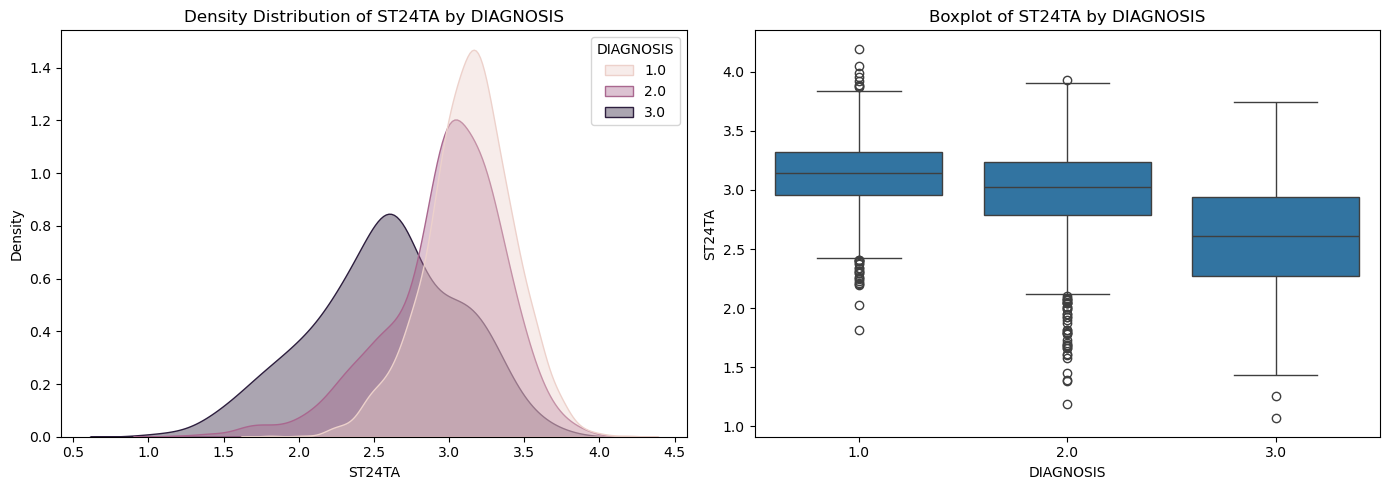

In [67]:
plot_diagnosis_distribution(ma_num, 'ST24TA')

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



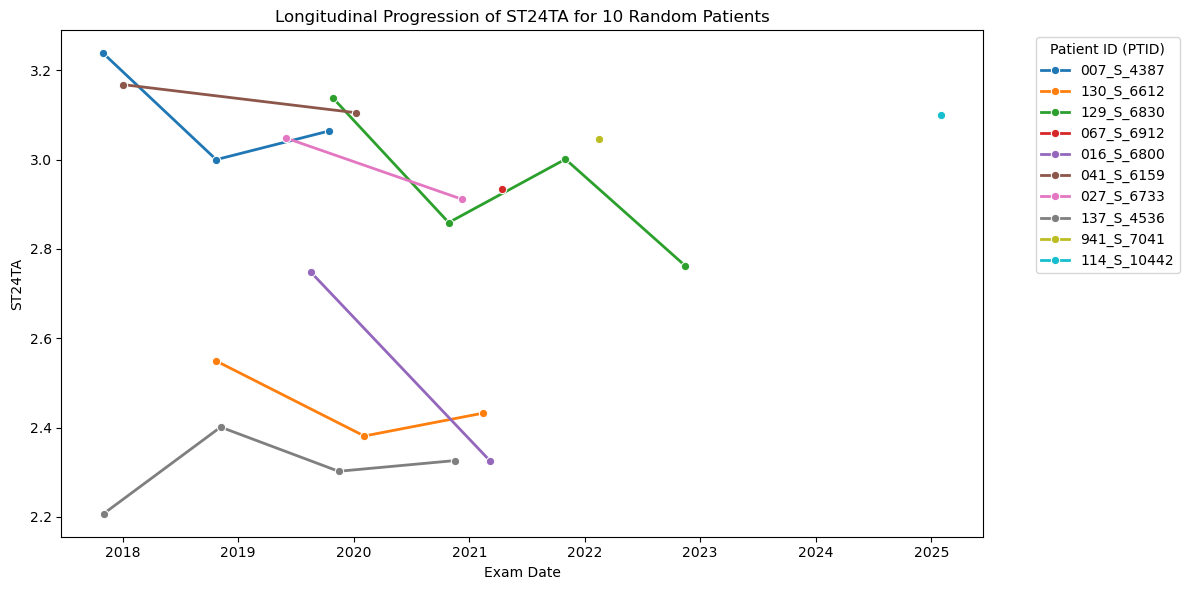

In [69]:
plot_patient_progression(table, 'ST24TA')

In [70]:
my_patients = list(patients.PTID.unique())

In [71]:
import random
cn_patients = random.choices(list(cn.PTID.unique()),k=50)
mci_patients = random.choices(list(mci.PTID.unique()),k=50)
ad_patients = random.choices(list(ad.PTID.unique()),k=50)

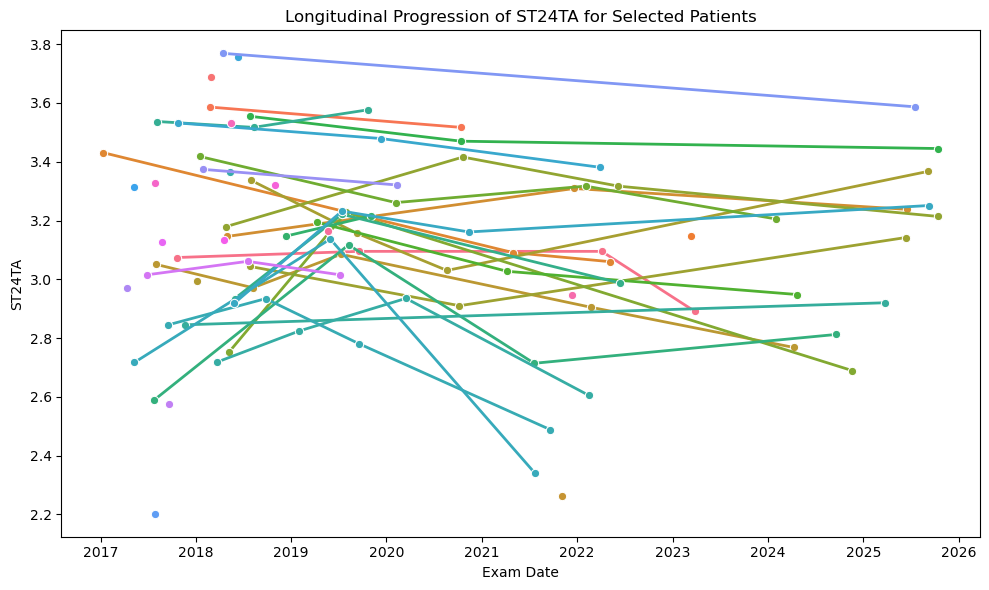

In [73]:
plot_specific_patients(table, 'ST24TA', cn_patients)